# Project 2: HMM Phoneme Recognizer

## Notebook Roadmap
1. Configure environment and data paths (Colab or VS Code/local).
2. Load train, validation, and test utterance lists.
3. Align time-stamped phoneme labels to frame-level labels.
4. Estimate HMM parameters from the training split only.
5. Visualize transition behavior.
6. Implement inference (Filtering, Viterbi and our own addition Smoothing) and evaluate performance.

This structure is designed so each section produces outputs required by the next one.

In [ ]:
import numpy as np
import os
from pathlib import Path
import scipy.stats
from scipy.special import logsumexp

In [312]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    data_root = Path('/content/drive/Shareddrives/AI_RU/project2/data')
except ModuleNotFoundError:
    data_root = Path('data')

## Section 1: Data Paths and Split Loading

We prepared consistent file paths and split lists for training, validation, and testing.

This section does two things:
1. Resolves dataset paths for both Colab and local VS Code execution.
2. Loads split files and matches feature files with label files.

In [313]:
feature_folder = data_root / '_out'
if not feature_folder.exists():
    feature_folder = data_root / 'out'

label_folder = data_root / 'cmu_us_slt_arctic' / 'lab'

txt_folder = data_root / 'txt'
if not txt_folder.exists():
    txt_folder = data_root / 'out'

In [314]:
with open(txt_folder / 'train.txt', 'r', encoding='utf-8') as f:
    train_filenames = [line.rstrip('\n') for line in f]
with open(txt_folder / 'test.txt', 'r', encoding='utf-8') as f:
    test_filenames = [line.rstrip('\n') for line in f]
with open(txt_folder / 'val.txt', 'r', encoding='utf-8') as f:
    val_filenames = [line.rstrip('\n') for line in f]

In [315]:
feature_files = [
    os.path.join(feature_folder, f)
    for f in os.listdir(feature_folder)
    if os.path.isfile(os.path.join(feature_folder, f)) and f.endswith('.npy')
]
feature_files = sorted(feature_files)

label_files = [
    os.path.join(label_folder, f)
    for f in os.listdir(label_folder)
    if os.path.isfile(os.path.join(label_folder, f)) and f.endswith('.lab')
]
label_files = sorted(label_files)

In [316]:
train_feature_files = []
train_label_files = []
val_feature_files = []
val_label_files = []
test_feature_files = []
test_label_files = []

train_filename_set = set(train_filenames)
val_filename_set = set(val_filenames)
test_filename_set = set(test_filenames)

for feature_idx, feature_filename in enumerate(feature_files):
    feature_basename = Path(feature_filename).stem

    if feature_basename in train_filename_set:
        train_feature_files.append(feature_filename)
        train_label_files.append(label_files[feature_idx])

    if feature_basename in val_filename_set:
        val_feature_files.append(feature_filename)
        val_label_files.append(label_files[feature_idx])

    if feature_basename in test_filename_set:
        test_feature_files.append(feature_filename)
        test_label_files.append(label_files[feature_idx])


## Section 2: Frame-Level Label Alignment

Here we converted each utterance from time-stamped labels to one phoneme label per feature frame.

This was very important because:
1. HMM training needs aligned frame and label sequences.
2. Feature vectors and labels must have exactly the same length.

In [317]:
def load_labels(label_file, arpabet_dic, n_frames, frame_step=0.01):
    label_array = np.genfromtxt(label_file, delimiter=" ", dtype=str)

    end_times = label_array[:, 0].astype(float)
    labels = label_array[:, 2]

    # frame times: 0.01, 0.02, ..., n_frames*frame_step
    frame_array = np.arange(1, n_frames + 1) * frame_step

    # for each end time, find how many frames are <= that boundary
    frame_ends = np.searchsorted(frame_array, end_times, side="left") + 1

    # convert cumulative frame counts into per-label counts
    counts = np.diff(np.r_[0, frame_ends])

    # repeat each label by its frame count
    states = np.repeat(labels, counts)
    
    # trim or pad to exactly n_frames
    states = states[:n_frames]

    if len(states) < n_frames:
        states = np.pad(states, (0, n_frames - len(states)), constant_values=labels[-1])

    states_num = np.array([arpabet_dic[p] for p in states], dtype=int)
    return states_num

## Section 3: Supervised HMM Parameter Estimation (Train Split)

Here we estimated the four core HMM components using aligned training data only.

Estimated parameters:
1. $\pi$: initial state distribution.
2. $A$: transition matrix.
3. $\mu$: per-phoneme emission mean vector.
4. $\Sigma$: per-phoneme emission covariance matrix.

In [318]:
ARPAbet_dic = {
    'aa': 0,
    'ae': 1,
    'ah': 2,
    'ao': 3,
    'aw': 4,
    'ay': 5,
    'b': 6,
    'ch': 7,
    'd': 8,
    'dh': 9,
    'eh': 10,
    'er': 11,
    'ey': 12,
    'f': 13,
    'g': 14,
    'hh': 15,
    'ih': 16,
    'iy': 17,
    'jh': 18,
    'k': 19,
    'l': 20,
    'm': 21,
    'n': 22,
    'ng': 23,
    'ow': 24,
    'oy': 25,
    'p': 26,
    'r': 27,
    's': 28,
    'sh': 29,
    't': 30,
    'th': 31,
    'uh': 32,
    'uw': 33,
    'v': 34,
    'w': 35,
    'y': 36,
    'z': 37,
    'zh': 38,
    'pau': 39,
    'ax': 40}
n_phonemes = len(ARPAbet_dic)

In [319]:
train_feature_list = []
for file in train_feature_files:
  feature_array = np.load(file)
  train_feature_list.append(feature_array)

val_feature_list = []
for file in val_feature_files:
  feature_array = np.load(file)
  val_feature_list.append(feature_array)

test_feature_list = []
for file in test_feature_files:
  feature_array = np.load(file)
  test_feature_list.append(feature_array)


In [320]:
train_label_list = []
for file_idx, label_file in enumerate(train_label_files):
  feature_array = train_feature_list[file_idx]
  n_frames = feature_array.shape[0]
  label_array = load_labels(label_file, ARPAbet_dic, n_frames)
  train_label_list.append(label_array)

val_label_list = []
for file_idx, label_file in enumerate(val_label_files):
  feature_array = val_feature_list[file_idx]
  n_frames = feature_array.shape[0]
  label_array = load_labels(label_file, ARPAbet_dic, n_frames)
  val_label_list.append(label_array)

test_label_list = []
for file_idx, label_file in enumerate(test_label_files):
  feature_array = test_feature_list[file_idx]
  n_frames = feature_array.shape[0]
  label_array = load_labels(label_file, ARPAbet_dic, n_frames)
  test_label_list.append(label_array)


In [321]:
start_state_counts = {}

for utterance in train_label_list:
    if len(utterance) == 0:
        continue
    first_phoneme = utterance[0]
    if first_phoneme in start_state_counts:
        start_state_counts[first_phoneme] += 1
    else:
        start_state_counts[first_phoneme] = 1


In [322]:
start_state_probs={}
for phoneme, count in start_state_counts.items():
    start_state_probs[phoneme] = count / len(train_label_list)

### 3.1 Initial Distribution $\pi$

We estimate $\pi$ from the first frame of each training utterance.

Why the first frame directly:
1. Skipping leading pauses would assign zero probability to 'pau' at t=0, which is wrong when many utterances genuinely start with silence.
2. Using utterance[0] gives an honest empirical estimate of what the first frame actually looks like in the training data.


In [323]:
initial_distribution = []
for phoneme in ARPAbet_dic.values():
  if phoneme in start_state_probs.keys():
    initial_distribution.append(start_state_probs[phoneme])
  else:
    initial_distribution.append(0)

### 3.2 Transition Matrix $A$

The transition matrix captures how phoneme states evolve over time:
$$a_{ij} = P(X_{t+1} = j | X_t = i)$$

Procedure:
1. Count all adjacent state pairs in training label sequences.
2. Normalize each row so it becomes a probability distribution.

In [324]:
transition_matrix = np.zeros((n_phonemes, n_phonemes))
for utterance in train_label_list:
    for t in range(len(utterance) - 1):
        current_state = utterance[t]
        next_state = utterance[t + 1]
        transition_matrix[current_state, next_state] += 1

### 3.3 Smoothing and Normalization

Before final normalization, we add a small constant $\alpha$ to every transition count.

Why this helps:
1. Avoids zero-probability transitions.
2. Improves robustness for rare transitions in limited data.

In [325]:
alpha = 0.001
transition_matrix = transition_matrix + alpha
normalisation_values = np.sum(transition_matrix, axis=1, keepdims=True)
transition_matrix = transition_matrix / normalisation_values

In [326]:
transition_matrix_plot = transition_matrix.copy()
np.fill_diagonal(transition_matrix_plot, 0)

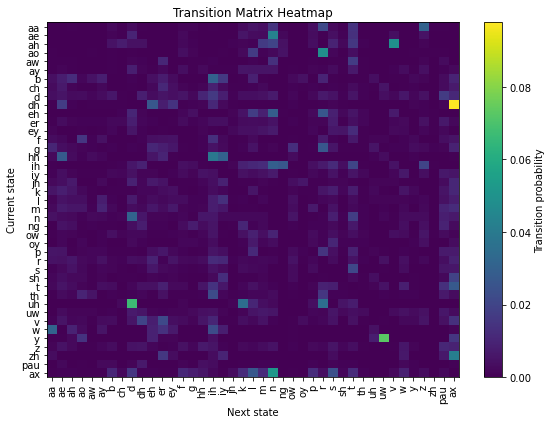

In [327]:
import matplotlib.pyplot as plt
import numpy as np

# transition_matrix: shape (n_states, n_states)
# phoneme_names: list of state names in the same order as the matrix rows/cols

plt.figure(figsize=(8, 6))
plt.imshow(transition_matrix_plot, aspect="auto")
plt.colorbar(label="Transition probability")

plt.xticks(ticks=np.arange(n_phonemes), labels=ARPAbet_dic.keys(), rotation=90)
plt.yticks(ticks=np.arange(n_phonemes), labels=ARPAbet_dic.keys())

plt.xlabel("Next state")
plt.ylabel("Current state")
plt.title("Transition Matrix Heatmap")
plt.tight_layout()
plt.show()

### 3.4 Emission Parameters ($\mu$, $\Sigma$)

Goal: estimate one Gaussian emission model per phoneme state.

Procedure:
1. Gather all training frames assigned to each phoneme.
2. Compute mean vector $\mu_i$ and covariance matrix $\Sigma_i$.
3. Apply covariance regularization ($\lambda I$) for numerical stability.

In [328]:
feature_mapping = [[] for _ in range(n_phonemes)]

for utterance_idx, utterance in enumerate(train_label_list):
    for label_idx, label in enumerate(utterance):
        row = train_feature_list[utterance_idx][label_idx, :]
        feature_mapping[label].append(row)

feature_mapping = [np.array(rows) for rows in feature_mapping]

In [329]:
emission_parameters = []
lam = 0.00001
feature_dim = train_feature_list[0].shape[1]
for phoneme in feature_mapping:
  if phoneme.shape[0] >= 2:
    mean = np.mean(phoneme, axis = 0)
    covariance = np.cov(phoneme, rowvar = False)
    covariance = covariance + np.eye(feature_dim) * lam
  elif phoneme.shape[0] == 1:
    mean = np.mean(phoneme, axis = 0)
    covariance = np.eye(feature_dim) * lam
  else:
    mean = np.zeros(feature_dim)
    covariance = np.eye(feature_dim) * lam

  emission_parameters.append([mean, covariance])

## Section 4: Inference Algorithms

We now move from parameter estimation to decoding.

Planned implementations:
1. Filtering (Forward algorithm) for frame-wise posterior state probabilities.
2. Viterbi decoding for the most likely phoneme path.
3. Smoothing (Optional decision).

### 4.1 Forward Algorithm (Filtering)

Goal: compute the posterior probability of each phoneme state at every frame, given all observations up to that point.

$$\alpha_i(t) = P(O_{1:t},\, X_t = i)$$

Procedure:
1. Initialise: $\alpha_i(1) = \pi_i \cdot p(o_1 \mid X_1 = i)$.
2. Propagate: $\alpha_j(t) = \left[\sum_i \alpha_i(t-1)\, a_{ij}\right] p(o_t \mid X_t = j)$.
3. Normalise $\alpha(\cdot)$ at each step so it sums to 1 (prevents underflow).
4. Emission log-probabilities are precomputed vectorised over all 41 phonemes before the time loop.

Output: a $(T \times 41)$ matrix where each row is the normalised posterior over phonemes at that frame.

In [ ]:
def forward_filtering(observations, pi, A, emission_params):
    """
    Forward filtering for an HMM in full log space.

    Parameters
    ----------
    observations : ndarray, shape (T, D)
        Sequence of observed feature vectors.
    pi : array-like, shape (K,)
        Initial state probabilities.
    A : ndarray, shape (K, K)
        Transition matrix where A[i, j] = p(z_t=j | z_{t-1}=i).
    emission_params : list of length K
        emission_params[i] = (mu_i, sigma_i) for state i.

    Returns
    -------
    log_alpha : ndarray, shape (T, K)
        Log posterior state probabilities at each time step, normalized so that
        exp(log_alpha[t]) sums to 1 for every t.
    """
    T = observations.shape[0]
    K = len(pi)

    log_alpha = np.full((T, K), -np.inf)

    # Safe logs for probabilities that may contain zeros
    pi = np.asarray(pi, dtype=float)
    A = np.asarray(A, dtype=float)

    log_pi = np.where(pi > 0, np.log(pi), -np.inf)
    log_A = np.where(A > 0, np.log(A), -np.inf)

    # Precompute emission log-probs: shape (T, K)
    log_emit_all = np.empty((T, K))
    for i in range(K):
        mu_i, sigma_i = emission_params[i]
        g = scipy.stats.multivariate_normal(mean=mu_i, cov=sigma_i, allow_singular=True)
        log_emit_all[:, i] = g.logpdf(observations)

    # Initialization:
    # log_alpha[0, i] ∝ log p(z_0=i) + log p(x_0 | z_0=i)
    log_alpha[0, :] = log_pi + log_emit_all[0, :]

    # Normalize in log space
    log_alpha[0, :] -= logsumexp(log_alpha[0, :])

    # Induction
    for t in range(1, T):
        # For each current state j:
        # log p(z_t=j,x_1:t) = log p(x_t|z_t=j) + logsumexp_i[log_alpha[t-1, i] + log_A[i, j]]
        log_pred = logsumexp(log_alpha[t - 1, :, None] + log_A, axis=0)
        log_alpha[t, :] = log_emit_all[t, :] + log_pred

        # Normalize so exp(log_alpha[t]) sums to 1
        log_norm = logsumexp(log_alpha[t, :])

        if np.isfinite(log_norm):
            log_alpha[t, :] -= log_norm
        else:
            # fallback: keep previous belief if everything invalidates
            log_alpha[t, :] = log_alpha[t - 1, :]

    return log_alpha


#### 4.1.1 Single-Utterance Test

Run filtering on one test utterance and report frame accuracy, this is just a quick sanity check before full evaluation.

In [331]:
# Pick the first test utterance
test_obs = test_feature_list[0]
alpha_result = forward_filtering(test_obs, initial_distribution, transition_matrix, emission_parameters)

print(f"Output Shape: {alpha_result.shape}") # Should be (T, 41)
print(f"Row sums (first 5): {np.sum(alpha_result[:5], axis=1)}") # Should all be 1.0

Output Shape: (334, 41)
Row sums (first 5): [          -inf -3301.49220131 -3945.79070117 -3406.48376398
 -3465.23218768]


/tmp/ipykernel_88249/1726108215.py:31: RuntimeWarning: divide by zero encountered in log
  log_pi = np.where(pi > 0, np.log(pi), -np.inf)


In [332]:
# Get the index of the highest probability phoneme for each frame
predictions = np.argmax(alpha_result, axis=1)

# Get the actual labels for the same utterance
ground_truth = test_label_list[0]

# Print a small slice to see if they look similar
print("Preds: ", predictions[50:70])
print("Truth: ", ground_truth[50:70])

Preds:  [11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11  2  2 34 34]
Truth:  [11 11 11 11 11 11 11 11 11 11 11 11  2  2  2  2  2 34 34 34]


In [333]:
accuracy = np.mean(predictions == ground_truth)
print(f"Utterance 0 Frame Accuracy: {accuracy * 100:.2f}%")

Utterance 0 Frame Accuracy: 61.68%


### 4.2 Viterbi Decoding

Goal: find the single most likely phoneme sequence given all observations.

$$\hat{X}_{1:T} = \arg\max_{X_{1:T}} P(X_{1:T} \mid O_{1:T})$$

Procedure:
1. Initialise: $\delta_i(1) = \log \pi_i + \log p(o_1 \mid X_1 = i)$.
2. Propagate: $\delta_j(t) = \max_i \left[\delta_i(t-1) + \log a_{ij}\right] + \log p(o_t \mid X_t = j)$.
3. Store backpointers $\psi_j(t) = \arg\max_i \left[\delta_i(t-1) + \log a_{ij}\right]$.
4. Traceback from $t = T$ using $\psi$ to recover the best path.

All operations stay in log-space (additions instead of multiplications) to avoid underflow. Emission log-probabilities are precomputed vectorised over all phonemes before the time loop.

Output: a length-$T$ array of phoneme indices, the most likely state sequence.

In [ ]:
def viterbi(observations, pi, A, emission_params):
    # matrix setup
    T = observations.shape[0]
    K = len(pi)
    delta = np.full((T, K), -np.inf) # log-prob of best path to (t, i)
    psi = np.zeros((T, K), dtype=int) # backpointers

    # Precompute log emission probs for ALL frames and ALL phonemes at once.
    log_emit_all = np.zeros((T, K))
    for i in range(K):
        mu_i, sigma_i = emission_params[i]
        g = scipy.stats.multivariate_normal(mean=mu_i, cov=sigma_i, allow_singular=True)
        log_emit_all[:, i] = g.logpdf(observations)

    # Precompute log_A once — A does not change between frames,
    # so computing it inside the frame loop was pure redundant work.
    log_A = np.log(np.where(A > 0, A, 1e-300))
    log_pi = np.log(np.where(np.array(pi) > 0, np.array(pi), 1e-300))

    # Initialization
    # combine with initial distribution (pi) in log domain
    delta[0, :] = log_pi + log_emit_all[0, :]
    # psi[0] unused, left as 0

    # Induction — inner phoneme loop eliminated: just index into log_emit_all
    for t in range(1, T):
        # scores[i, j] = delta[t-1, i] + log_A[i, j]
        # find the best previous state for each current state j
        scores = delta[t - 1, :, np.newaxis] + log_A # (K, K)
        psi[t, :] = np.argmax(scores, axis=0) # best predecessor for each j
        delta[t, :] = np.max(scores, axis=0) + log_emit_all[t, :]

    # Backtracking
    best_path = np.zeros(T, dtype=int)
    best_path[T - 1] = np.argmax(delta[T - 1]) # best final state
    for t in range(T - 2, -1, -1):
        best_path[t] = psi[t + 1, best_path[t + 1]] # follow backpointers

    return best_path


#### 4.2.1 Single-Utterance Test

Run Viterbi on one test utterance and report frame accuracy.

In [335]:
# Pick the first test utterance
test_obs = test_feature_list[0]
viterbi_result = viterbi(test_obs, initial_distribution, transition_matrix, emission_parameters)
print(f"Output Shape: {viterbi_result.shape}")  # Should be (T,)
print(f"All valid phoneme indices: {np.all((viterbi_result >= 0) & (viterbi_result < n_phonemes))}")  # Should be True

Output Shape: (334,)
All valid phoneme indices: True


In [336]:
# Get the actual labels for the same utterance
ground_truth = test_label_list[0]

# Print a small slice to see if they look similar
print("Preds: ", viterbi_result[50:70])
print("Truth: ", ground_truth[50:70])

Preds:  [11 11 11 11 11 11 11 11 11 11 11 11 11 11 11  2  2  2 34 34]
Truth:  [11 11 11 11 11 11 11 11 11 11 11 11  2  2  2  2  2 34 34 34]


In [337]:
accuracy = np.mean(viterbi_result == ground_truth)
print(f"Utterance 0 Frame Accuracy: {accuracy * 100:.2f}%")

Utterance 0 Frame Accuracy: 67.37%


### 4.3 Smoothing

Goal: compute the most accurate probability distribution over the hidden states for a specific moment in time, given the entire sequence of observations, both past and future.

$$P(X_t | O_{1:T})$$

Procedure:

**1. Forward Pass ($\alpha$):** Computes the joint probability of the past observations and current state.
* **Init ($t=1$):** $\alpha_i(1) = \pi_i P(O_1 | X_1 = i)$
* **Recurse ($t>1$):** $\alpha_j(t) = P(O_t | X_t = j) \sum_{i} \alpha_i(t-1) a_{ij}$

**2. Backward Pass ($\beta$):** Computes the conditional probability of future observations given the current state.
* **Init ($t=T$):** $\beta_i(T) = 1$
* **Recurse ($t<T$):** $\beta_i(t) = \sum_{j} a_{ij} P(O_{t+1} | X_{t+1} = j) \beta_j(t+1)$

**3. Combine & Decode ($\gamma$):** Computes the smoothed posterior probability for each frame independently.
* **Combine:** $\gamma_i(t) \propto \alpha_i(t) \beta_i(t)$ *(Normalize over all states $i$ to sum to $1$)*
* **Decode:** $X_t^* = \arg\max_i \gamma_i(t)$

In [ ]:
def predict_smoothing_labels(features, log_pi=None, log_A=None, emission_params=None):
    """
    Computes the most likely state for each frame independently using Forward-Backward Smoothing.
    """
    if log_pi is None:
        log_pi = log_pi_smoothing
    if log_A is None:
        log_A = log_A_smoothing
    if emission_params is None:
        emission_params = emission_parameters

    T = features.shape[0]
    K = len(log_pi)

    # Precompute Emission Log-Probabilities
    log_B = np.zeros((T, K))
    for i, (mu_i, sigma_i) in enumerate(emission_params):
        g = scipy.stats.multivariate_normal(mean=mu_i, cov=sigma_i, allow_singular=True)
        log_B[:, i] = g.logpdf(features)

    # FORWARD PASS (Calculates log_alpha)
    log_alpha = np.zeros((T, K))
    log_alpha[0, :] = log_pi + log_B[0, :]

    for t in range(1, T):
        temp = log_alpha[t-1, :, np.newaxis] + log_A
        # Use logsumexp instead of max() to sum the probability mass
        log_alpha[t, :] = logsumexp(temp, axis=0) + log_B[t, :]

    # BACKWARD PASS (Calculates log_beta)
    log_beta = np.zeros((T, K))
    # log_beta[-1, :] is already 0.0, which represents log(1)

    for t in range(T - 2, -1, -1):
        temp = log_A + log_B[t+1, :] + log_beta[t+1, :]
        log_beta[t, :] = logsumexp(temp, axis=1)

    # COMBINE & DECODE (Calculates log_gamma)
    log_gamma = log_alpha + log_beta

    # Pick the state with the highest smoothed probability for each frame independently
    best_frames = np.argmax(log_gamma, axis=1)

    return best_frames


In [339]:
# Precompute log-space versions of π and A for smoothing
log_pi_smoothing = np.log(np.where(np.array(initial_distribution) > 0,
                                    np.array(initial_distribution), 1e-300))
log_A_smoothing  = np.log(np.where(transition_matrix > 0, transition_matrix, 1e-300))


#### 4.3.1 Single-Utterance Test

Run smoothing on one test utterance and report frame accuracy.

In [340]:
# Pick the first test utterance
test_obs = test_feature_list[0]
smoothing_result = predict_smoothing_labels(test_obs)

print(f'Output shape: {smoothing_result.shape}')  # Should be (T,)
print(f'All valid phoneme indices: {np.all((smoothing_result >= 0) & (smoothing_result < n_phonemes))}')


Output shape: (334,)
All valid phoneme indices: True


In [341]:
# Get the actual labels for the same utterance
ground_truth = test_label_list[0]

# Print a small slice to compare
print('Preds: ', smoothing_result[50:70])
print('Truth: ', ground_truth[50:70])

accuracy = np.mean(smoothing_result == ground_truth)
print(f'Utterance 0 Frame Accuracy: {accuracy * 100:.2f}%')


Preds:  [11 11 11 11 11 11 11 11 11 11 11 11 11 11 11  2  2  2 34 34]
Truth:  [11 11 11 11 11 11 11 11 11 11 11 11  2  2  2  2  2 34 34 34]
Utterance 0 Frame Accuracy: 67.96%


## Section 5: Evaluation

We now evaluate the three decoding algorithms on training, testing and validating sets.

It includes:
- Frame-level accuracy.
- Confusion matrices on the test split.
- Per-phoneme precision and recall on the test split.
- Example utterances comparing predicted and ground-truth phoneme sequences.

### 5.1 Evaluation Utilities

Helper functions used throughout this section:

- `predict_filtering_labels` / `predict_viterbi_labels` — wrap each decoder to return a frame-level label array.
- `evaluate_decoder` — runs a decoder over up to `max_eval_utterances` utterances, prints throughput, and returns aggregated results.
- `compute_confusion_matrix` / `compute_precision_recall` — aggregate confusion statistics and per-phoneme metrics.
- `plot_confusion_matrix` / `print_per_phoneme_table` — visualise results.
- `collapse_frame_labels` — this function was created for section 5.4 in order to distinguish visually the differences of predicted phonemes in a utterance.

In [342]:
id_to_phoneme = {idx: phoneme for phoneme, idx in ARPAbet_dic.items()}
phoneme_names = [id_to_phoneme[i] for i in range(n_phonemes)]


def predict_filtering_labels(observations):
    posterior = forward_filtering(observations, initial_distribution, transition_matrix, emission_parameters)
    return np.argmax(posterior, axis=1)


def predict_viterbi_labels(observations):
    return viterbi(observations, initial_distribution, transition_matrix, emission_parameters)


def evaluate_decoder(feature_list, label_list, predict_fn, split_name, method_name, max_utterances=None, progress_every=1):
    from time import perf_counter

    n_total = len(feature_list)
    n_eval = n_total if max_utterances is None else min(max_utterances, n_total)

    y_true_all = []
    y_pred_all = []

    start_time = perf_counter()
    last_report_time = start_time
    last_report_idx = 0

    for idx in range(n_eval):
        observations = feature_list[idx]
        y_true = label_list[idx]
        y_pred = predict_fn(observations)

        if len(y_true) != len(y_pred):
            raise ValueError(
                f"Length mismatch in utterance {idx}: true={len(y_true)}, pred={len(y_pred)}"
            )

        y_true_all.append(y_true.astype(int))
        y_pred_all.append(y_pred.astype(int))

        if (idx + 1) % progress_every == 0 or (idx + 1) == n_eval:
            now = perf_counter()
            elapsed = now - start_time
            interval_elapsed = now - last_report_time
            interval_count = (idx + 1) - last_report_idx

            avg_utt_per_sec = (idx + 1) / elapsed if elapsed > 0 else 0.0
            recent_utt_per_sec = interval_count / interval_elapsed if interval_elapsed > 0 else 0.0

            print(
                f"{method_name} on {split_name}: {idx + 1}/{n_eval} "
                f"| avg {avg_utt_per_sec:.2f} utt/s "
                f"| recent {recent_utt_per_sec:.2f} utt/s "
                f"| elapsed {elapsed:.1f}s"
            )

            last_report_time = now
            last_report_idx = idx + 1

    y_true_flat = np.concatenate(y_true_all)
    y_pred_flat = np.concatenate(y_pred_all)

    total_elapsed = perf_counter() - start_time
    overall_utt_per_sec = n_eval / total_elapsed if total_elapsed > 0 else 0.0

    return {
        "split": split_name,
        "method": method_name,
        "n_utterances": n_eval,
        "n_frames": int(len(y_true_flat)),
        "frame_accuracy": float(np.mean(y_true_flat == y_pred_flat)),
        "elapsed_sec": float(total_elapsed),
        "utterances_per_sec": float(overall_utt_per_sec),
        "y_true": y_true_flat,
        "y_pred": y_pred_flat,
    }


def compute_confusion_matrix(y_true, y_pred, n_classes):
    confusion = np.zeros((n_classes, n_classes), dtype=np.int64)
    np.add.at(confusion, (y_true, y_pred), 1)
    return confusion


def compute_precision_recall(confusion):
    true_positive = np.diag(confusion).astype(float)
    predicted_positive = np.sum(confusion, axis=0).astype(float)
    actual_positive = np.sum(confusion, axis=1).astype(float)

    precision = np.divide(
        true_positive,
        predicted_positive,
        out=np.zeros_like(true_positive),
        where=predicted_positive > 0,
    )
    recall = np.divide(
        true_positive,
        actual_positive,
        out=np.zeros_like(true_positive),
        where=actual_positive > 0,
    )
    support = actual_positive.astype(int)
    return precision, recall, support


def print_per_phoneme_table(precision, recall, support, top_n=None):
    rows = []
    for i in range(n_phonemes):
        rows.append((phoneme_names[i], precision[i], recall[i], support[i]))

    rows.sort(key=lambda row: row[2], reverse=True)  # sort by recall descending

    if top_n is None:
        top_n = len(rows)

    print(f"{'phoneme':>8}  {'precision':>9}  {'recall':>7}  {'support':>7}")
    for phoneme, prec, rec, sup in rows[:top_n]:
        print(f"{phoneme:>8}  {prec:9.3f}  {rec:7.3f}  {sup:7d}")


def plot_confusion_matrix(confusion, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(confusion, cmap='Blues', aspect='auto')
    plt.colorbar(label='Frame count')
    ticks = np.arange(n_phonemes)
    plt.xticks(ticks=ticks, labels=phoneme_names, rotation=90, fontsize=7)
    plt.yticks(ticks=ticks, labels=phoneme_names, fontsize=7)
    plt.xlabel('Predicted phoneme')
    plt.ylabel('True phoneme')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def collapse_frame_labels(frame_labels):
    symbols = [phoneme_names[int(x)] for x in frame_labels]
    collapsed = []
    for symbol in symbols:
        if not collapsed or symbol != collapsed[-1]:
            collapsed.append(symbol)
    return collapsed




### 5.2 Run Frame Accuracy Evaluation

Set `max_eval_utterances` to `None` for full evaluation, or to a smaller number (for example, `50`) for a quicker debug run.

This cell prints throughput during execution in utterances per second (`utt/s`) and reports total runtime per method at the end.

In [343]:
max_eval_utterances = None

filter_train_eval = evaluate_decoder(
    train_feature_list, train_label_list, predict_filtering_labels,
    split_name='train', method_name='Filtering', max_utterances=max_eval_utterances,
)
filter_val_eval = evaluate_decoder(
    val_feature_list, val_label_list, predict_filtering_labels,
    split_name='val', method_name='Filtering', max_utterances=max_eval_utterances,
)
filter_test_eval = evaluate_decoder(
    test_feature_list, test_label_list, predict_filtering_labels,
    split_name='test', method_name='Filtering', max_utterances=max_eval_utterances,
)

viterbi_train_eval = evaluate_decoder(
    train_feature_list, train_label_list, predict_viterbi_labels,
    split_name='train', method_name='Viterbi', max_utterances=max_eval_utterances,
)
viterbi_val_eval = evaluate_decoder(
    val_feature_list, val_label_list, predict_viterbi_labels,
    split_name='val', method_name='Viterbi', max_utterances=max_eval_utterances,
)
viterbi_test_eval = evaluate_decoder(
    test_feature_list, test_label_list, predict_viterbi_labels,
    split_name='test', method_name='Viterbi', max_utterances=max_eval_utterances,
)

smoothing_train_eval = evaluate_decoder(
    train_feature_list, train_label_list, predict_smoothing_labels,
    split_name='train', method_name='Smoothing', max_utterances=max_eval_utterances,
)
smoothing_val_eval = evaluate_decoder(
    val_feature_list, val_label_list, predict_smoothing_labels,
    split_name='val', method_name='Smoothing', max_utterances=max_eval_utterances,
)
smoothing_test_eval = evaluate_decoder(
    test_feature_list, test_label_list, predict_smoothing_labels,
    split_name='test', method_name='Smoothing', max_utterances=max_eval_utterances,
)

summary_rows = [
    filter_train_eval,  filter_val_eval,  filter_test_eval,
    viterbi_train_eval, viterbi_val_eval, viterbi_test_eval,
    smoothing_train_eval, smoothing_val_eval, smoothing_test_eval,
]

print('Frame accuracy summary')
print(f"{'method':>10}  {'split':>7}  {'utt':>6}  {'frames':>8}  {'frame_acc':>10}  {'utt/s':>8}  {'time(s)':>8}")
for row in summary_rows:
    print(
        f"{row['method']:>10}  {row['split']:>7}  {row['n_utterances']:6d}  {row['n_frames']:8d}  "
        f"{row['frame_accuracy'] * 100:9.2f}%  {row['utterances_per_sec']:8.2f}  {row['elapsed_sec']:8.1f}"
    )


/tmp/ipykernel_88249/1726108215.py:31: RuntimeWarning: divide by zero encountered in log
  log_pi = np.where(pi > 0, np.log(pi), -np.inf)


Filtering on train: 1/792 | avg 6.50 utt/s | recent 6.50 utt/s | elapsed 0.2s
Filtering on train: 2/792 | avg 9.31 utt/s | recent 16.38 utt/s | elapsed 0.2s
Filtering on train: 3/792 | avg 7.82 utt/s | recent 5.93 utt/s | elapsed 0.4s


Filtering on train: 4/792 | avg 6.52 utt/s | recent 4.35 utt/s | elapsed 0.6s
Filtering on train: 5/792 | avg 6.64 utt/s | recent 7.20 utt/s | elapsed 0.8s
Filtering on train: 6/792 | avg 6.68 utt/s | recent 6.86 utt/s | elapsed 0.9s
Filtering on train: 7/792 | avg 6.59 utt/s | recent 6.10 utt/s | elapsed 1.1s
Filtering on train: 8/792 | avg 6.79 utt/s | recent 8.59 utt/s | elapsed 1.2s
Filtering on train: 9/792 | avg 6.79 utt/s | recent 6.78 utt/s | elapsed 1.3s
Filtering on train: 10/792 | avg 7.12 utt/s | recent 12.83 utt/s | elapsed 1.4s
Filtering on train: 11/792 | avg 7.09 utt/s | recent 6.78 utt/s | elapsed 1.6s
Filtering on train: 12/792 | avg 7.42 utt/s | recent 15.36 utt/s | elapsed 1.6s
Filtering on train: 13/792 | avg 7.49 utt/s | recent 8.36 utt/s | elapsed 1.7s
Filtering on train: 14/792 | avg 7.70 utt/s | recent 12.05 utt/s | elapsed 1.8s
Filtering on train: 15/792 | avg 7.55 utt/s | recent 5.93 utt/s | elapsed 2.0s
Filtering on train: 16/792 | avg 7.58 utt/s | recent 8.

### 5.3 Confusion Matrix and Per-Phoneme Precision/Recall (Test Set)

Goal: identify which phonemes are most confused with each other and which are well-separated.

- The confusion matrix shows, for each true phoneme $i$, the distribution of predicted phonemes across all test frames.
- Per-phoneme precision and recall highlight systematic errors.

Requires the test predictions from Section 5.2 to be computed first.

Filtering confusion matrix shape: (41, 41)
Viterbi confusion matrix shape: (41, 41)


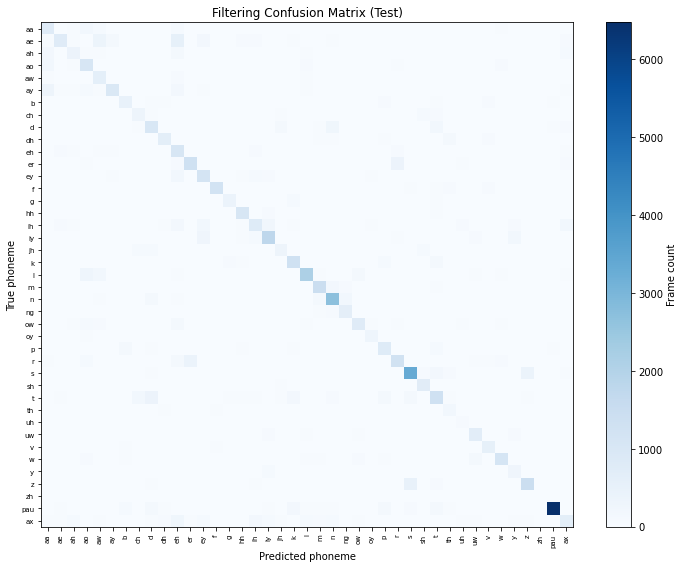

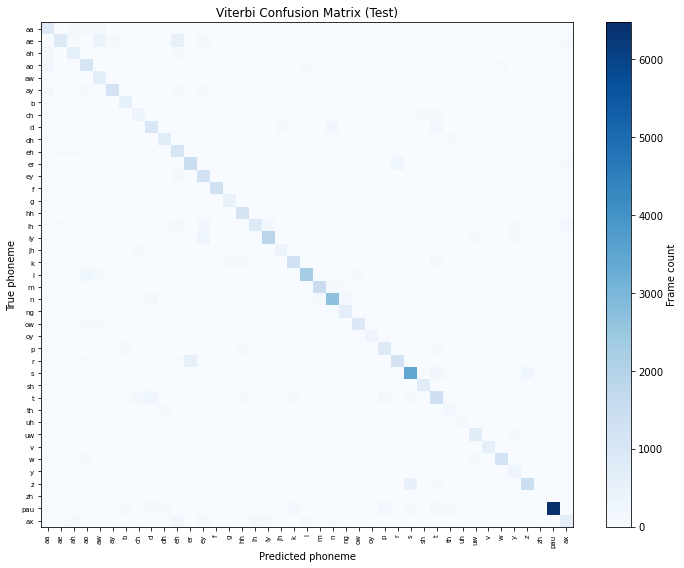


Per-phoneme precision/recall - Filtering
 phoneme  precision   recall  support
      sh      0.707    0.885      819
     pau      0.963    0.855     7576
       s      0.804    0.798     4159
       n      0.733    0.780     3449
       f      0.859    0.779     1540
       m      0.684    0.755     1888
      ng      0.612    0.749      824
       k      0.616    0.740     1757
      hh      0.698    0.714     1461
       l      0.776    0.687     3079
       z      0.684    0.682     2094
      eh      0.342    0.674     1565
      iy      0.701    0.666     2660
       w      0.733    0.665     1653
      aw      0.394    0.663      882
      ey      0.548    0.655     1719
      oy      0.580    0.651      444
      uw      0.572    0.644     1030
      ao      0.511    0.643     1617
       v      0.609    0.642      862
       p      0.531    0.635     1263
      er      0.684    0.632     2071
       g      0.587    0.600      655
       b      0.531    0.589      820
       y

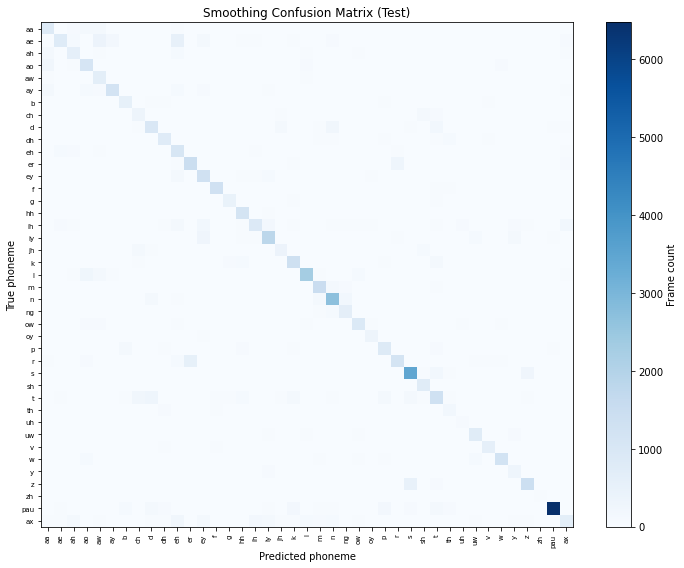


Per-phoneme precision/recall - Smoothing
 phoneme  precision   recall  support
      sh      0.687    0.910      819
     pau      0.961    0.854     7576
       s      0.801    0.832     4159
       f      0.854    0.831     1540
       m      0.712    0.788     1888
       n      0.751    0.782     3449
      hh      0.696    0.764     1461
      ng      0.605    0.758      824
       k      0.629    0.750     1757
       l      0.808    0.743     3079
      aw      0.419    0.738      882
      ey      0.586    0.736     1719
       w      0.781    0.725     1653
      uw      0.618    0.718     1030
      oy      0.673    0.709      444
      er      0.656    0.696     2071
       g      0.661    0.692      655
       y      0.411    0.687      435
      iy      0.727    0.683     2660
       z      0.726    0.670     2094
      ao      0.559    0.666     1617
      ow      0.686    0.666     1353
       b      0.588    0.665      820
      eh      0.400    0.663     1565
      dh

In [ ]:
if 'filter_test_eval' not in globals() or 'viterbi_test_eval' not in globals() or 'smoothing_test_eval' not in globals():
    raise RuntimeError('Run the full evaluation cell in Section 5.2 before this cell.')

filter_test_confusion = compute_confusion_matrix(
    filter_test_eval['y_true'],
    filter_test_eval['y_pred'],
    n_phonemes,
)

viterbi_test_confusion = compute_confusion_matrix(
    viterbi_test_eval['y_true'],
    viterbi_test_eval['y_pred'],
    n_phonemes,
)

print('Filtering confusion matrix shape:', filter_test_confusion.shape)
print('Viterbi confusion matrix shape:', viterbi_test_confusion.shape)

plot_confusion_matrix(filter_test_confusion, 'Filtering Confusion Matrix (Test)')
plot_confusion_matrix(viterbi_test_confusion, 'Viterbi Confusion Matrix (Test)')

print('\nPer-phoneme precision/recall - Filtering')
f_precision, f_recall, f_support = compute_precision_recall(filter_test_confusion)
print_per_phoneme_table(f_precision, f_recall, f_support)

print('\nPer-phoneme precision/recall - Viterbi')
v_precision, v_recall, v_support = compute_precision_recall(viterbi_test_confusion)
print_per_phoneme_table(v_precision, v_recall, v_support)

smoothing_test_confusion = compute_confusion_matrix(
    smoothing_test_eval['y_true'],
    smoothing_test_eval['y_pred'],
    n_phonemes,
)

print('Smoothing confusion matrix shape:', smoothing_test_confusion.shape)

plot_confusion_matrix(smoothing_test_confusion, 'Smoothing Confusion Matrix (Test)')

print('\nPer-phoneme precision/recall - Smoothing')
s_precision, s_recall, s_support = compute_precision_recall(smoothing_test_confusion)
print_per_phoneme_table(s_precision, s_recall, s_support)


### 5.4 Example Utterances: Predicted vs Ground Truth

Goal: analyze how our decoders work against the real data.

Each utterance is collapsed from frame-level to phoneme-level (consecutive identical frames merged), then displayed as a side-by-side comparison of ground truth and predicted phoneme sequences.

In [345]:
example_indices = [0, 1, 2, 3, 4, 5]
max_frames_to_show = 40

for idx in example_indices:
    observations = test_feature_list[idx]
    y_true = test_label_list[idx]
    y_filter = predict_filtering_labels(observations)
    y_viterbi = predict_viterbi_labels(observations)
    y_smoothing = predict_smoothing_labels(observations)

    to_names = lambda arr: [id_to_phoneme[int(x)] for x in arr[:max_frames_to_show]]

    print(f'\nUtterance index: {idx}')
    print('Ground truth:', ' '.join(to_names(y_true)))
    print('Filtering:   ', ' '.join(to_names(y_filter)))
    print('Viterbi:     ', ' '.join(to_names(y_viterbi)))
    print('Smoothing:   ', ' '.join(to_names(y_smoothing)))
    print(
        f"Frame accuracy -> Filtering: {np.mean(y_filter == y_true) * 100:.2f}%, "
        f"Viterbi: {np.mean(y_viterbi == y_true) * 100:.2f}%, "
        f"Smoothing: {np.mean(y_smoothing == y_true) * 100:.2f}%"
    )


/tmp/ipykernel_88249/1726108215.py:31: RuntimeWarning: divide by zero encountered in log
  log_pi = np.where(pi > 0, np.log(pi), -np.inf)



Utterance index: 0
Ground truth: pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau ao ao ao ao ao ao ao ao ao ao ao ao ao ao ao ao th th th th th
Filtering:    pau pau pau k k k k k pau pau pau b k t t t t t b p p ay ay ao ao ao ao ao ao ao ao ao ao ah ah ah th f f f
Viterbi:      pau pau pau k k k pau pau pau pau pau t t t t t t p p p p ao ao ao ao ao ao ao ao ao ao ao ah ah ah f f f f f
Smoothing:    pau pau pau k k k pau pau pau pau pau t t t t t t p p p p ao ao ao ao ao ao ao ao ao ao ao ah ah ah f f f f f
Frame accuracy -> Filtering: 61.68%, Viterbi: 67.37%, Smoothing: 67.96%

Utterance index: 1
Ground truth: pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau pau l l l l l l l l l l ao ao ao ao ao ao ao ao
Filtering:    pau pau pau pau pau pau pau pau pau pau pau pau pau pau k k d d t t t y w w w l l l l l l l l l l ao ao ao ao ao
Viterbi:      pau pau pau pau pau pau pau pau pau pau pau pau pau pau k k t t t t y y ax ax 